# Modelo de predicción de temperatura — Caja de Compostaje PLA


Este notebook entrena un modelo de red neuronal que predice si el calefactor debe encenderse en la **próxima medición**, basándose en la temperatura actual y el estado actual del calefactor.



## 1. Importar librerías

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers

## 2. Configuración de umbrales

Ajusta estos valores según tu rango objetivo de temperatura.

In [ ]:
TEMP_MIN = 37   # Por debajo de este valor → etiqueta 1 (encender calefactor)
TEMP_MAX = 40   # Por encima de este valor  → etiqueta 0 (apagar calefactor)
# Entre TEMP_MIN y TEMP_MAX → etiqueta -1 (zona de transición)

## 3. Cargar y limpiar los datos

**Sube tus archivos CSV a Colab** o ejecuta la celda de carga interactiva.

In [ ]:
from google.colab import files
uploaded = files.upload()  # Sube temp_casaLau.csv y temp_act.csv

Saving temp_act (37-40).csv to temp_act (37-40).csv
Saving temp_casaLau_DEF.csv to temp_casaLau_DEF.csv


In [ ]:
# --- Cargar datos de temperatura ambiente, o sea, sin calefactor en estas sesiones ---
df_ambiente = pd.read_csv('temp_casaLau_DEF.csv', usecols=['timestamp_real', 'tiempo_seg', 'temperatura_C'])
df_ambiente['heater_state'] = 0

# --- Cargar datos de sesiones con calefactor activo ---
df_calefactor = pd.read_csv('temp_act (37-40).csv', usecols=['timestamp_real', 'tiempo_seg', 'temperatura_C', 'heater_state'])

# Eliminar filas con NaN en las columnas clave
df_calefactor = df_calefactor.dropna(subset=['temperatura_C', 'heater_state'])
df_calefactor['heater_state'] = df_calefactor['heater_state'].astype(int)

# --- Combinar los dos datasets ---
df = pd.concat([df_ambiente, df_calefactor], ignore_index=True)

# Ordenar cronológicamente por timestamp
df['timestamp_real'] = pd.to_datetime(df['timestamp_real'])
df = df.sort_values('timestamp_real').reset_index(drop=True)

print(f'Total de filas combinadas: {len(df)}')
print(f'Rango de temperatura: {df["temperatura_C"].min():.2f}°C — {df["temperatura_C"].max():.2f}°C')
print(f'Distribución heater_state:\n{df["heater_state"].value_counts()}')
df.head()

Total de filas combinadas: 788
Rango de temperatura: 14.13°C — 46.13°C
Distribución heater_state:
heater_state
1    414
0    374
Name: count, dtype: int64


,timestamp_real,tiempo_seg,temperatura_C,heater_state
0,2026-05-01 12:38:22,240,23.12,0
1,2026-05-01 14:12:01,600,23.25,0
2,2026-05-01 14:22:01,1200,22.94,0
3,2026-05-01 14:32:01,1800,22.87,0
4,2026-05-01 14:42:01,2400,22.62,0



El modelo aprenderá a predecir **si en la próxima medición la temperatura estará fuera del rango**, no el estado actual. En esta seccion se agrega las etiquetas temp_siguiente y etiqueta futura


In [ ]:
df['temp_siguiente'] = df['temperatura_C'].shift(-1)

# Eliminar última fila (no tiene siguiente)
df = df.dropna(subset=['temp_siguiente']).reset_index(drop=True)

# Etiqueta futura basada en la temperatura SIGUIENTE
def etiquetar_futuro(temp_futura):
    if temp_futura < TEMP_MIN:
        return 1   # En x min estará frío → enciende ahora
    elif temp_futura > TEMP_MAX:
        return 0   # En x min seguirá caliente → apaga
    else:
        return -1  # Zona de transición

df['etiqueta_futura'] = df['temp_siguiente'].apply(etiquetar_futuro)

# Distribución de etiquetas
print('Distribución de etiqueta_futura:')
print(df['etiqueta_futura'].value_counts())

df[['temperatura_C', 'heater_state', 'temp_siguiente', 'etiqueta_futura']].head(10)

Distribución de etiqueta_futura:
etiqueta_futura
 1    551
-1    137
 0     99
Name: count, dtype: int64


,temperatura_C,heater_state,temp_siguiente,etiqueta_futura
0,23.12,0,23.25,1
1,23.25,0,22.94,1
2,22.94,0,22.87,1
3,22.87,0,22.62,1
4,22.62,0,22.87,1
5,22.87,0,22.87,1
6,22.87,0,23.31,1
7,23.31,0,23.00,1
8,23.00,0,23.06,1
9,23.06,0,23.00,1


In [ ]:
# Excluir filas en zona de transición (-1) para el entrenamiento
# Estas filas son ambiguas y pueden confundir al modelo
df_train_data = df[df['etiqueta_futura'] != -1].reset_index(drop=True)

print(f'Filas disponibles para entrenamiento: {len(df_train_data)}')
print(f'  → Etiqueta 1 (encender): {(df_train_data["etiqueta_futura"] == 1).sum()}')
print(f'  → Etiqueta 0 (apagar):   {(df_train_data["etiqueta_futura"] == 0).sum()}')

Filas disponibles para entrenamiento: 650
  → Etiqueta 1 (encender): 551
  → Etiqueta 0 (apagar):   99


## 5. Visualización de los datos

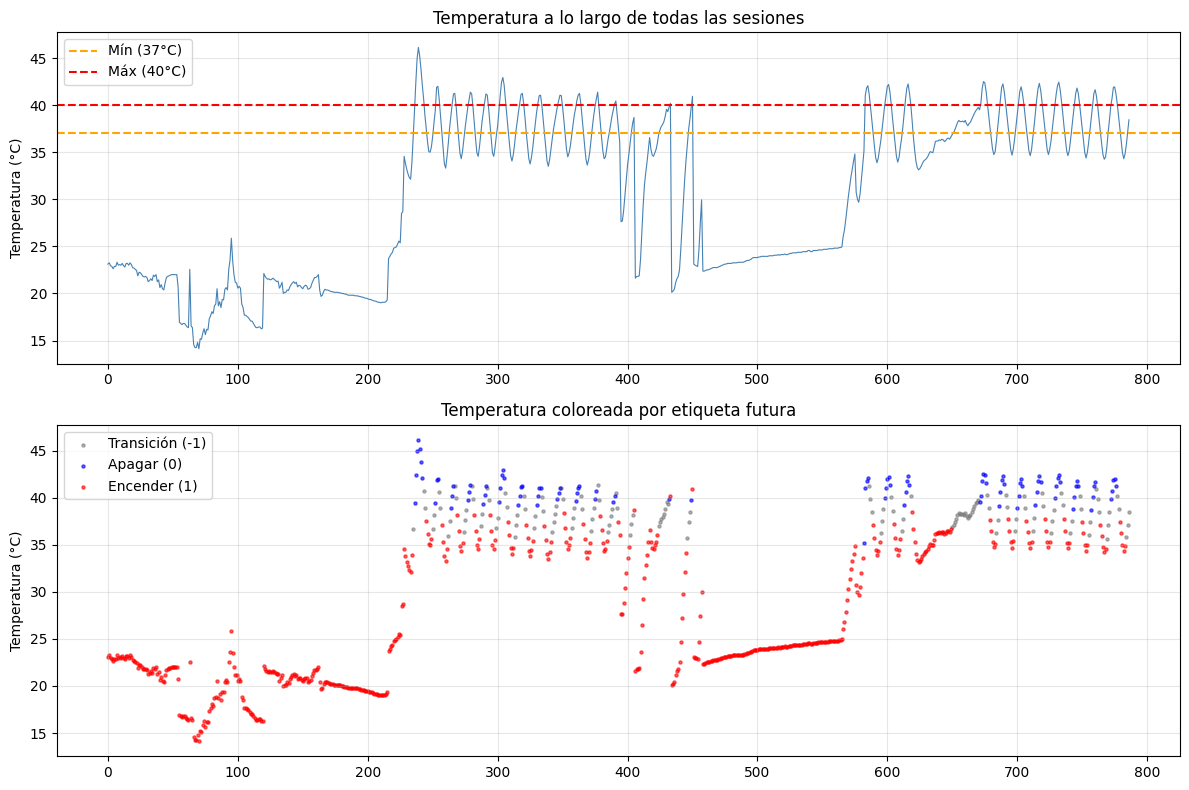

In [ ]:
fig, axs = plt.subplots(2, 1, figsize=(12, 8))

# Temperatura a lo largo del tiempo
axs[0].plot(df['temperatura_C'].values, color='steelblue', linewidth=0.8)
axs[0].axhline(TEMP_MIN, color='orange', linestyle='--', label=f'Mín ({TEMP_MIN}°C)')
axs[0].axhline(TEMP_MAX, color='red', linestyle='--', label=f'Máx ({TEMP_MAX}°C)')
axs[0].set_title('Temperatura a lo largo de todas las sesiones')
axs[0].set_ylabel('Temperatura (°C)')
axs[0].legend()
axs[0].grid(True, alpha=0.3)

# Temperatura coloreada por etiqueta futura
colores = {1: 'red', 0: 'blue', -1: 'gray'}
for etiqueta, grupo in df.groupby('etiqueta_futura'):
    label = {1: 'Encender (1)', 0: 'Apagar (0)', -1: 'Transición (-1)'}[etiqueta]
    axs[1].scatter(grupo.index, grupo['temperatura_C'],
                   c=colores[etiqueta], s=5, label=label, alpha=0.6)
axs[1].set_title('Temperatura coloreada por etiqueta futura')
axs[1].set_ylabel('Temperatura (°C)')
axs[1].legend()
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Preparar caracteristicas y normalizar

**Entradas:** `temperatura_C` y `heater_state`  
**Label de salida:** `etiqueta_futura`

In [ ]:
# Extraer entradas y labels como arrays numpy
X = df_train_data[['temperatura_C', 'heater_state']].values.astype(np.float32)
y = df_train_data['etiqueta_futura'].values.astype(np.float32)


# Normalizar temperatura al rango [0, 1] para que la red aprenda mejor
# heater_state ya está en [0, 1], no necesita normalización
temp_min_norm = 18
temp_max_norm = 50
X[:, 0] = (X[:, 0] - temp_min_norm) / (temp_max_norm - temp_min_norm)

print(f'Rango de normalización: {temp_min_norm:.2f}°C — {temp_max_norm:.2f}°C')
print(f'Guarda estos valores para usarlos en el firmware del ESP32:')
print(f'  TEMP_MIN_NORM = {temp_min_norm:.4f}')
print(f'  TEMP_MAX_NORM = {temp_max_norm:.4f}')

Rango de normalización: 18.00°C — 50.00°C
Guarda estos valores para usarlos en el firmware del ESP32:
  TEMP_MIN_NORM = 18.0000
  TEMP_MAX_NORM = 50.0000

Shape X: (650, 2), Shape y: (650,)


## 7. División del dataset
La división del dataset sigue el esquema **60% Training / 20% Validation / 20% Test**.

Total muestras:     650
Training (60%):     390
Validation (20%):   130
Test (20%):         130


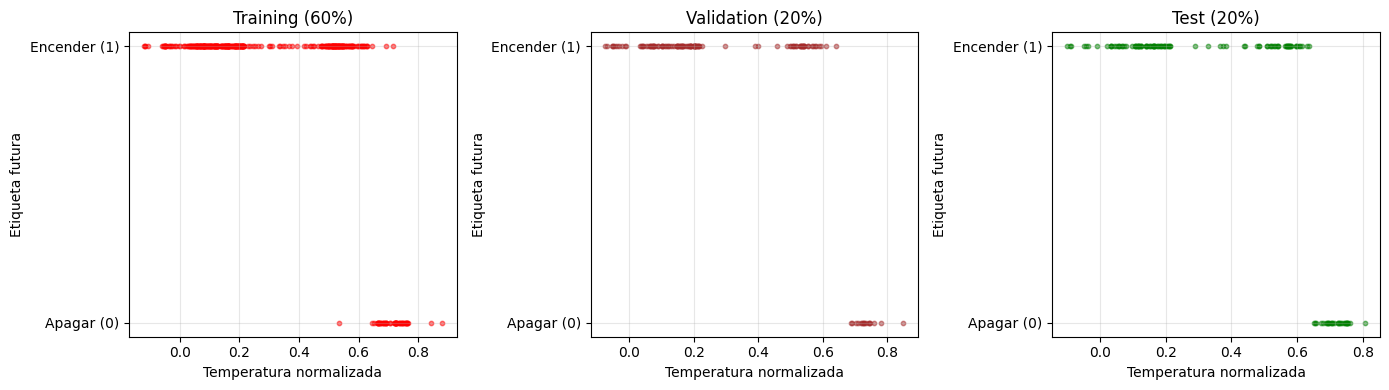

In [ ]:
samples = len(X)

# Mezclar aleatoriamente antes de dividir
indices = np.random.permutation(samples)
X = X[indices]
y = y[indices]

# Calcular índices de corte
train_split = int(0.6 * samples)
test_split  = int(0.2 * samples) + train_split

# Dividir con np.split
x_train,    x_validate, x_test = np.split(X, [train_split, test_split])
y_train,    y_validate, y_test = np.split(y, [train_split, test_split])

print(f'Total muestras:     {samples}')
print(f'Training (60%):     {len(x_train)}')
print(f'Validation (20%):   {len(x_validate)}')
print(f'Test (20%):         {len(x_test)}')

# Visualizar distribución de cada split
fig, axs = plt.subplots(1, 3, figsize=(14, 4))
splits = [
    (x_train,    y_train,    'Training (60%)',    'red'),
    (x_validate, y_validate, 'Validation (20%)',  'brown'),
    (x_test,     y_test,     'Test (20%)',         'green')
]

for ax, (x, y_s, title, color) in zip(axs, splits):
    ax.scatter(x[:, 0], y_s, c=color, s=10, alpha=0.5)
    ax.set_title(title)
    ax.set_xlabel('Temperatura normalizada')
    ax.set_ylabel('Etiqueta futura')
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Apagar (0)', 'Encender (1)'])
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Construir la red neuronal

- **Entrada:** 2 nodos (temperatura normalizada + heater_state)
- **Capas ocultas:** 2 capas de 16 nodos con activación ReLU
- **Salida:** 1 nodo con activación sigmoid (resultado entre 0 y 1)

In [ ]:
model = tf.keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=(2,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(1,  activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',  # Para clasificación binaria (0 o 1)
    metrics=['mae', 'accuracy']
)

#model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## 9. Entrenar el modelo

In [ ]:
history = model.fit(
    x_train, y_train,
    epochs=300,
    batch_size=16,
    validation_data=(x_validate, y_validate),
    verbose=1
)

Epoch 1/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.8590 - loss: 0.6263 - mae: 0.4625 - val_accuracy: 0.8692 - val_loss: 0.5939 - val_mae: 0.4427
Epoch 2/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8590 - loss: 0.5655 - mae: 0.4240 - val_accuracy: 0.8692 - val_loss: 0.5369 - val_mae: 0.4033
Epoch 3/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8590 - loss: 0.5100 - mae: 0.3823 - val_accuracy: 0.8692 - val_loss: 0.4790 - val_mae: 0.3565
Epoch 4/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8590 - loss: 0.4536 - mae: 0.3353 - val_accuracy: 0.8692 - val_loss: 0.4320 - val_mae: 0.3119
Epoch 5/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8590 - loss: 0.4091 - mae: 0.2949 - val_accuracy: 0.8692 - val_loss: 0.3938 - val_mae: 0.2739
Epoch 6/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8590 - loss: 0.3723 - mae: 0.2599 - val_accuracy: 0.8692 - val_loss: 0.3601 - val_mae: 0.2422
Epoch 7/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 

## 10. Visualizar el entrenamiento

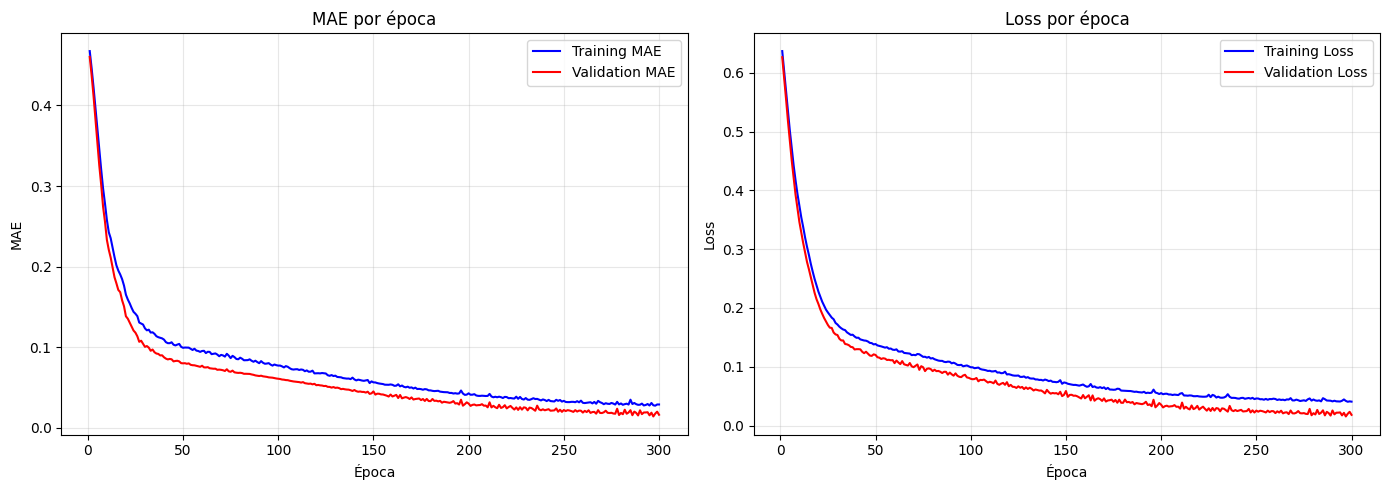

In [ ]:
epochs_range = range(1, len(history.history['mae']) + 1)

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# MAE
axs[0].plot(epochs_range, history.history['mae'],     'b', label='Training MAE')
axs[0].plot(epochs_range, history.history['val_mae'], 'r', label='Validation MAE')
axs[0].set_title('MAE por época')
axs[0].set_xlabel('Época')
axs[0].set_ylabel('MAE')
axs[0].legend()
axs[0].grid(True, alpha=0.3)

# Loss
axs[1].plot(epochs_range, history.history['loss'],     'b', label='Training Loss')
axs[1].plot(epochs_range, history.history['val_loss'], 'r', label='Validation Loss')
axs[1].set_title('Loss por época')
axs[1].set_xlabel('Época')
axs[1].set_ylabel('Loss')
axs[1].legend()
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Evaluar en el set de Test

Loss en Test:     0.0176
MAE en Test:      0.0160
Accuracy en Test: 100.0%
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


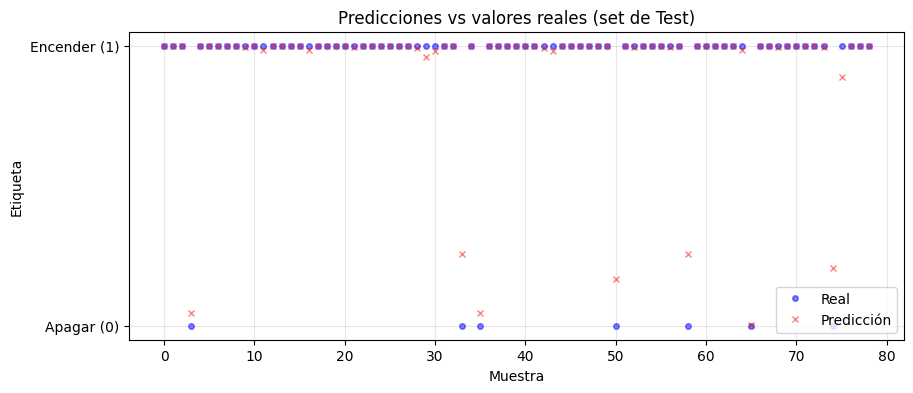

In [ ]:
loss, mae, acc = model.evaluate(x_test, y_test, verbose=0)
print(f'Loss en Test:     {loss:.4f}')
print(f'MAE en Test:      {mae:.4f}')
print(f'Accuracy en Test: {acc*100:.1f}%')

# Predicciones vs valores reales
predictions = model.predict(x_test).flatten()
predictions_binarias = (predictions >= 0.5).astype(int)

plt.figure(figsize=(10, 4))
plt.plot(y_test, 'o', color='blue', markersize=4, label='Real', alpha=0.5)
plt.plot(predictions, 'x', color='red', markersize=4, label='Predicción', alpha=0.5)
plt.title('Predicciones vs valores reales (set de Test)')
plt.xlabel('Muestra')
plt.ylabel('Etiqueta')
plt.yticks([0, 1], ['Apagar (0)', 'Encender (1)'])
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 12. Convertir a TFLite y generar `model.h`

Este archivo se incluye directamente en el firmware del ESP32.

In [ ]:
# Convertir a TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Guardar el archivo .tflite
open('arduino_model.tflite', 'wb').write(tflite_model)

# Generar model.h
!echo 'const unsigned char model[] = {' > /content/model.h
!cat arduino_model.tflite | xxd -i >> /content/model.h
!echo '};' >> /content/model.h

print('model.h generado correctamente.')
print(f'Tamaño del modelo TFLite: {len(tflite_model)} bytes')

Saved artifact at '/tmp/tmp57ev5ox0'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 2), dtype=tf.float32, name='keras_tensor_20')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  134915186761104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134914991842000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134914991842576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134914991835280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134914991839888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134914991841808: TensorSpec(shape=(), dtype=tf.resource, name=None)
model.h generado correctamente.
Tamaño del modelo TFLite: 3464 bytes


In [ ]:
#Descargar archivo
from google.colab import files
files.download('/content/model.h')
files.download('arduino_model.tflite')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 14. Valores de normalización para el firmware

**Copia estos valores al código Arduino.** El ESP32 debe normalizar la temperatura antes de pasársela al modelo, usando exactamente los mismos valores que se usaron aquí.

```cpp
// En el firmware del ESP32:
// const float TEMP_MIN_NORM = <valor impreso en celda 6>;
// const float TEMP_MAX_NORM = <valor impreso en celda 6>;

float normalizar(float temp) {
  return (temp - TEMP_MIN_NORM) / (TEMP_MAX_NORM - TEMP_MIN_NORM);
}
```

In [ ]:
5print(f'const float TEMP_MIN_NORM = {temp_min_norm:.4f}f;')
print(f'const float TEMP_MAX_NORM = {temp_max_norm:.4f}f;')

const float TEMP_MIN_NORM = 18.0000f;
const float TEMP_MAX_NORM = 75.0000f;
